# Example of Gradient

The examples used in this article [https://yao-chih.netlify/from-gradient-descent-to-stochastic-gradient-descent/](https://yao-chih.netlify/from-gradient-descent-to-stochastic-gradient-descent/).

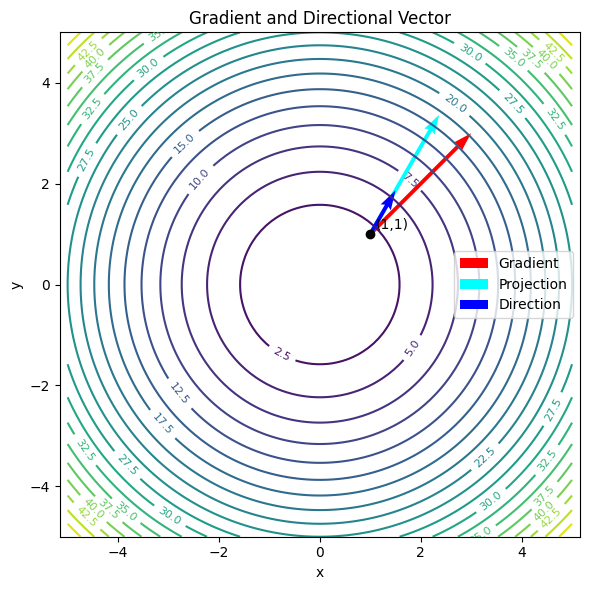

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Define the height function H(x,y) = x^2 + y^2
def H(x, y):
    return x ** 2 + y ** 2

# Define the point (x0, y0)
x0, y0 = 1, 1

# Calculate gradient
grad = np.array([2 * x0, 2 * y0])  # ∇H = (2x, 2y)

# Define the direction unit vector
theta = np.radians(60)
u = np.array([np.cos(theta), np.sin(theta)])

# Calculate directional derivatives = grad · u
proj = np.dot(grad, u) * u

# Range
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = H(X, Y)

# Contour lines
plt.figure(figsize=(6, 6))
contour = plt.contour(X, Y, Z, levels=20, cmap="viridis")
plt.clabel(contour, inline=True, fontsize=8)

# Vectors
plt.quiver(x0, y0, grad[0], grad[1], angles='xy', scale_units='xy', scale=1, color="red", label="Gradient")
plt.quiver(x0, y0, proj[0], proj[1], angles='xy', scale_units='xy', scale=1, color="cyan", label="Projection")
plt.quiver(x0, y0, u[0], u[1], angles='xy', scale_units='xy', scale=1, color="blue", label="Direction")

# Mark the points
plt.scatter(x0, y0, color="black")
plt.text(x0+0.1, y0+0.1, f"({x0},{y0})")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Gradient and Directional Vector")
plt.axis("equal")
plt.tight_layout()
plt.savefig("gradient_example.webp", dpi=300)
plt.show()


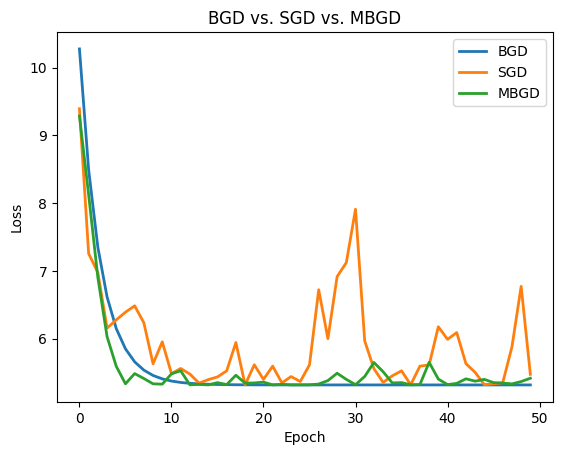

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# loss function f(x) = (x-3)^2
def loss(x, data):
    return np.mean((x - data)**2)

def grad(x, data):
    return np.mean(2 * (x - data))

# simulation data
np.random.seed(0)
data = 3 + np.random.uniform(low=-4, high=4, size=100)

# hyperparameters
lr = 0.1
epochs = 50

# initialization
x_bgd, x_sgd, x_mbgd = 0.0, 0.0, 0.0
history_bgd, history_sgd, history_mbgd = [], [], []

# gradient descent
for epoch in range(epochs):
    # BGD
    g = grad(x_bgd, data)
    x_bgd -= lr * g
    history_bgd.append(loss(x_bgd, data))
    
    # SGD
    i = np.random.randint(len(data))
    g = 2 * (x_sgd - data[i])
    x_sgd -= lr * g
    history_sgd.append(loss(x_sgd, data))
    
    # MBGD
    batch_idx = np.random.choice(len(data), size=5, replace=False)
    g = grad(x_mbgd, data[batch_idx])
    x_mbgd -= lr * g
    history_mbgd.append(loss(x_mbgd, data))

# plotting the loss curves
plt.plot(history_bgd, label="BGD", linewidth=2)
plt.plot(history_sgd, label="SGD", linewidth=2)
plt.plot(history_mbgd, label="MBGD", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("BGD vs. SGD vs. MBGD")
plt.savefig("methods_comparison.webp", dpi=300)
plt.show()
